In [1]:

import os
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision.transforms as T
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score



In [ ]:
# 1. Load and split df
#####################################
excel_path = "D:/Ruslan/main.xlsx"
df = pd.read_excel(excel_path)

def assign_split(row):
    img_name = row['IMG name']
    cond_str = row['Condition'].lower().strip()
    if cond_str == 'clean':
        return 'test' if 428 <= img_name <= 603 else 'train_val'
    elif cond_str == 'water':
        return 'test' if 1006 <= img_name <= 1156 else 'train_val'
    elif cond_str == 'dust':
        return 'test' if 2901 <= img_name <= 3029 else 'train_val'
    elif cond_str == 'snow':
        return 'test' if 3370 <= img_name <= 3630 else 'train_val'
    return 'train_val'

df['Split'] = df.apply(assign_split, axis=1)
test_df = df[df['Split'] == 'test'].copy()
train_val_df = df[df['Split'] == 'train_val'].copy()

label_mapping = {'clean': 0, 'dust': 1, 'snow': 2, 'water': 3}

train_df, val_df = train_test_split(
    train_val_df, test_size=0.1875, random_state=42,
    stratify=train_val_df['Condition']
)

print("Train size:", len(train_df))
print("Val   size:", len(val_df))
print("Test  size:", len(test_df))

Train size: 2846
Val   size: 657
Test  size: 717


In [3]:
# 2. Dataset & Dataloader
#####################################
class VoltageCurrentDataset(data.Dataset):
    def __init__(self, df, img_dir, transform=None,
                 voltage_min=0.623, voltage_max=22.08,
                 current_min=0.03, current_max=2.29):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.voltage_min = voltage_min
        self.voltage_max = voltage_max
        self.current_min = current_min
        self.current_max = current_max

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['IMG name']
        condition = row['Condition'].lower().strip()
        filename = os.path.join(self.img_dir, f"{int(img_name)}.jpg")
        image = Image.open(filename).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = label_mapping[condition]
        v_raw = float(row['Voltage, V'])
        i_raw = float(row['Current, A'])
        v_norm = (v_raw - self.voltage_min) / (self.voltage_max - self.voltage_min)
        i_norm = (i_raw - self.current_min) / (self.current_max - self.current_min)
        # Our proposed box format: (voltage_norm, current_norm, 0, 0)
        box = torch.tensor([v_norm, i_norm, 0.0, 0.0], dtype=torch.float32)
        return image, label, box

transform = T.Compose([T.Resize((224,224)), T.ToTensor()])
img_dir = "D:/Ruslan/main"

train_dataset = VoltageCurrentDataset(train_df, img_dir, transform=transform)
val_dataset   = VoltageCurrentDataset(val_df,   img_dir, transform=transform)
test_dataset  = VoltageCurrentDataset(test_df,  img_dir, transform=transform)

batch_size = 32
train_loader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = data.DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [4]:
# 3. Model Definition with Weight Initialization
#####################################
class EfficientNetLite2(nn.Module):
    def __init__(self, num_classes=4):
        super(EfficientNetLite2, self).__init__()
        backbone = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        num_fmap_channels = 1408

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(num_fmap_channels, num_classes)
        )

        self.bbox_regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.2),
            nn.Linear(num_fmap_channels, 4)
        )
        # Initialize new layers with Kaiming Uniform initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
        for m in self.bbox_regressor.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        class_logits = self.classifier(x)
        box_preds = self.bbox_regressor(x)
        return class_logits, box_preds


In [8]:
# 4. Training, Evaluation, and Visualization Functions
#####################################
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    correct_class = 0
    all_true_boxes = []
    all_pred_boxes = []
    
    with torch.no_grad():
        for images, labels, boxes in loader:
            images = images.to(device)
            labels = labels.to(device)
            boxes  = boxes.to(device)
            
            class_logits, box_preds = model(images)
            loss_cls = F.cross_entropy(class_logits, labels)
            loss_reg = F.mse_loss(box_preds, boxes)
            loss = loss_cls + loss_reg
            total_loss += loss.item()
            total_samples += images.size(0)
            preds = class_logits.argmax(dim=1)
            correct_class += (preds == labels).sum().item()
            all_true_boxes.append(boxes.cpu())
            all_pred_boxes.append(box_preds.cpu())
    
    avg_loss = total_loss / len(loader)
    all_true_boxes = torch.cat(all_true_boxes, dim=0).numpy()
    all_pred_boxes = torch.cat(all_pred_boxes, dim=0).numpy()
    regression_mse = np.mean((all_true_boxes - all_pred_boxes) ** 2)
    r2 = r2_score(all_true_boxes[:, :2], all_pred_boxes[:, :2])
    accuracy = correct_class / total_samples
    return avg_loss, regression_mse, r2, accuracy

def train_model(model, train_loader, val_loader, device, epochs=200, lr=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.to(device)
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, labels, boxes in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            boxes  = boxes.to(device)
            optimizer.zero_grad()
            class_logits, box_preds = model(images)
            loss_cls = F.cross_entropy(class_logits, labels)
            loss_reg = F.mse_loss(box_preds, boxes)
            loss = loss_cls + loss_reg
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Evaluate model on training and validation data
        train_loss, train_reg_mse, train_r2, train_acc = evaluate(model, train_loader, device)
        val_loss, val_reg_mse, val_r2, val_acc = evaluate(model, val_loader, device)
        val_losses.append(val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  [Train] Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Reg MSE: {train_reg_mse:.4f}, R2: {train_r2}")
        print(f"  [Val  ] Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, Reg MSE: {val_reg_mse:.4f}, R2: {val_r2}")
        
        # Save the model if validation loss improved
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            print("  Best model saved!")
    
    # Plot loss curves after training
    plt.figure(figsize=(10,6))
    plt.plot(range(1, epochs+1), train_losses, label="Train Loss")
    plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Curves")
    plt.legend()
    plt.show()
    
    return model

In [9]:
# Utility functions for denormalization and formatting
voltage_min, voltage_max = 0.623, 22.08
current_min, current_max = 0.03, 2.29

def denorm_box(box):
    v = box[0] * (voltage_max - voltage_min) + voltage_min
    i = box[1] * (current_max - current_min) + current_min
    return [v, i]

def format_list(values):
    return "[" + ", ".join([f"{v:.4f}" for v in values]) + "]"

def visualize_predictions(model, loader, device):
    model.eval()
    samples = {cls: [] for cls in range(4)}
    with torch.no_grad():
        for images, labels, boxes in loader:
            images = images.to(device)
            class_logits, box_preds = model(images)
            probs = F.softmax(class_logits, dim=1).cpu().numpy()
            box_preds = box_preds.cpu().numpy()
            labels = labels.cpu().numpy()
            boxes = boxes.cpu().numpy()
            images_cpu = images.cpu()
            for i in range(len(images_cpu)):
                lbl = labels[i]
                if len(samples[lbl]) < 10:
                    pred_box_denorm = denorm_box(box_preds[i])
                    true_box_denorm = denorm_box(boxes[i])
                    samples[lbl].append({
                        'image': images_cpu[i],
                        'true_label': lbl,
                        'pred_probs': probs[i],
                        'pred_box': pred_box_denorm,
                        'true_box': true_box_denorm
                    })
            if all(len(s_list) >= 10 for s_list in samples.values()):
                break

    for cls in sorted(samples.keys()):
        class_samples = samples[cls]
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        fig.suptitle(f'Class {cls} Samples', fontsize=16)
        for idx, ax in enumerate(axes.flatten()):
            if idx < len(class_samples):
                sample = class_samples[idx]
                img = sample['image'].permute(1, 2, 0).numpy()
                true_box_str = format_list(sample['true_box'])
                pred_box_str = format_list(sample['pred_box'])
                pred_probs_str = format_list(sample['pred_probs'])
                ax.imshow(img)
                ax.set_title(
                    f"True (V,I): {true_box_str}\n"
                    f"Pred (V,I): {pred_box_str}\n"
                    f"Prob: {pred_probs_str}"
                )
                ax.axis("off")
            else:
                ax.axis("off")
        plt.tight_layout()
        plt.show()

Epoch [1/100]
  [Train] Loss: 0.0696, Acc: 0.9982, Reg MSE: 0.0479, R2: 0.3263537585735321
  [Val  ] Loss: 0.0900, Acc: 0.9924, Reg MSE: 0.0559, R2: 0.2180076539516449
  Best model saved!
Epoch [2/100]
  [Train] Loss: 0.0314, Acc: 0.9996, Reg MSE: 0.0232, R2: 0.6413959264755249
  [Val  ] Loss: 0.0436, Acc: 1.0000, Reg MSE: 0.0301, R2: 0.5339857935905457
  Best model saved!
Epoch [3/100]
  [Train] Loss: 0.0180, Acc: 1.0000, Reg MSE: 0.0137, R2: 0.7905350923538208
  [Val  ] Loss: 0.0267, Acc: 1.0000, Reg MSE: 0.0197, R2: 0.6969119310379028
  Best model saved!
Epoch [4/100]
  [Train] Loss: 0.0127, Acc: 1.0000, Reg MSE: 0.0094, R2: 0.8512434959411621
  [Val  ] Loss: 0.0190, Acc: 1.0000, Reg MSE: 0.0137, R2: 0.7739104628562927
  Best model saved!
Epoch [5/100]
  [Train] Loss: 0.0100, Acc: 1.0000, Reg MSE: 0.0072, R2: 0.8857719302177429
  [Val  ] Loss: 0.0145, Acc: 1.0000, Reg MSE: 0.0105, R2: 0.828645646572113
  Best model saved!
Epoch [6/100]
  [Train] Loss: 0.0076, Acc: 1.0000, Reg MSE: 0

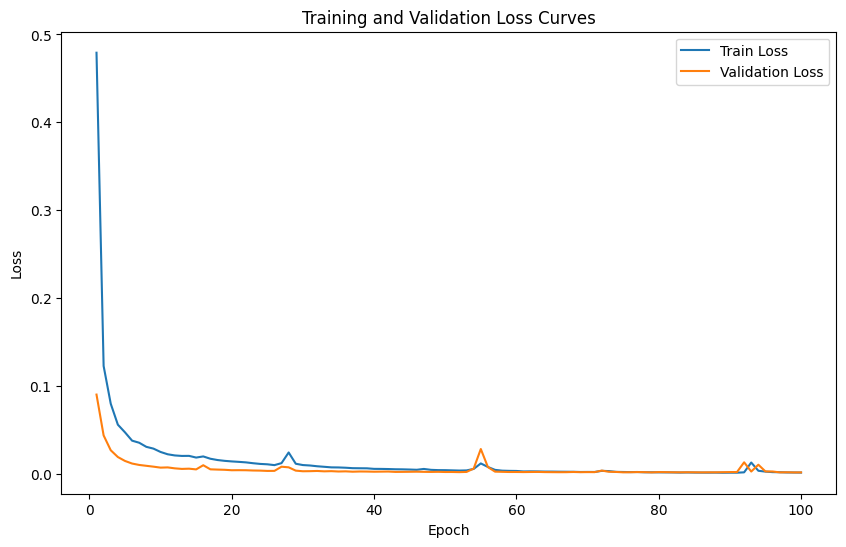

Final checkpoint saved at final_model_checkpoint.pt
Test Loss: 0.1137, Test Reg MSE: 0.0319, Test R^2: 0.3187, Test Accuracy: 0.9763


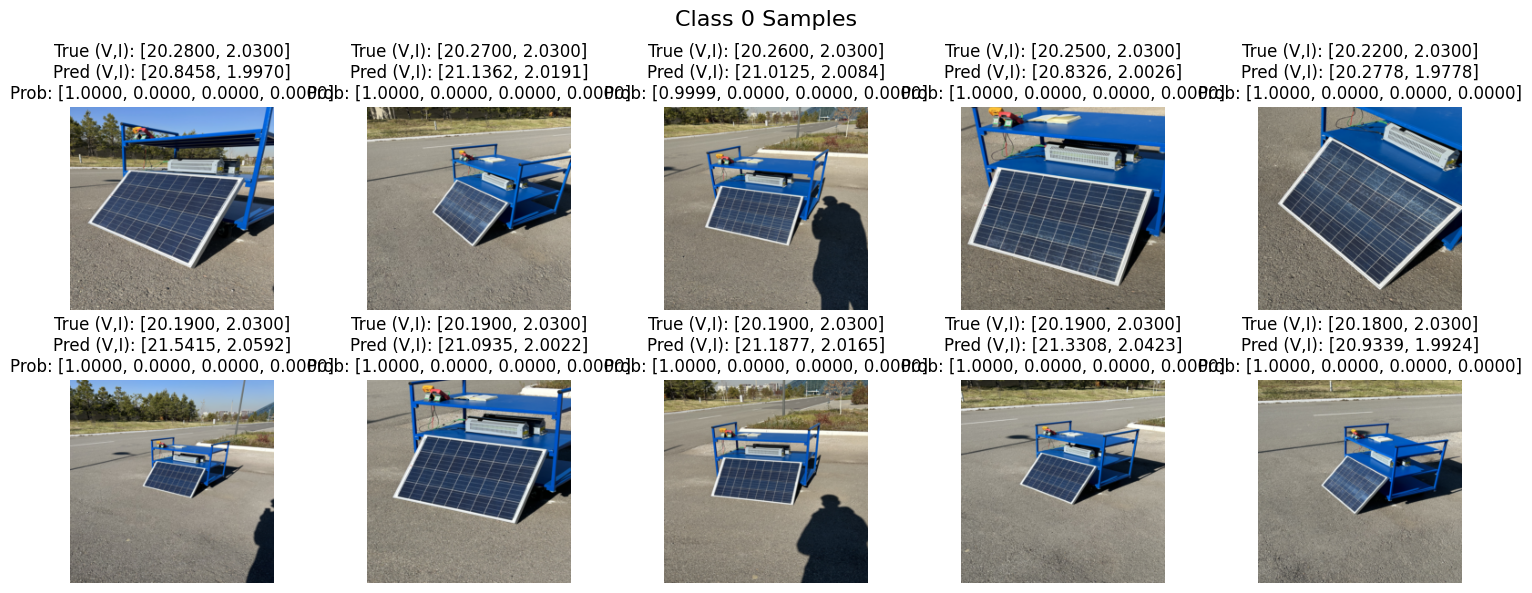

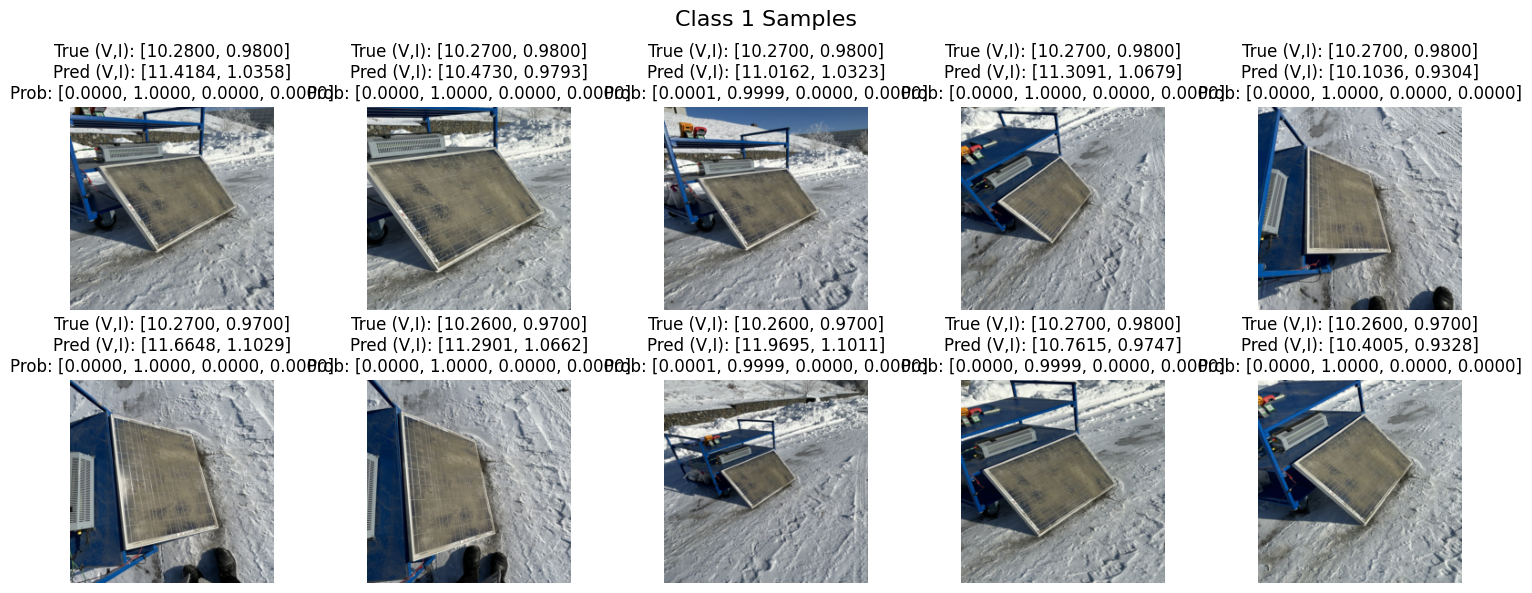

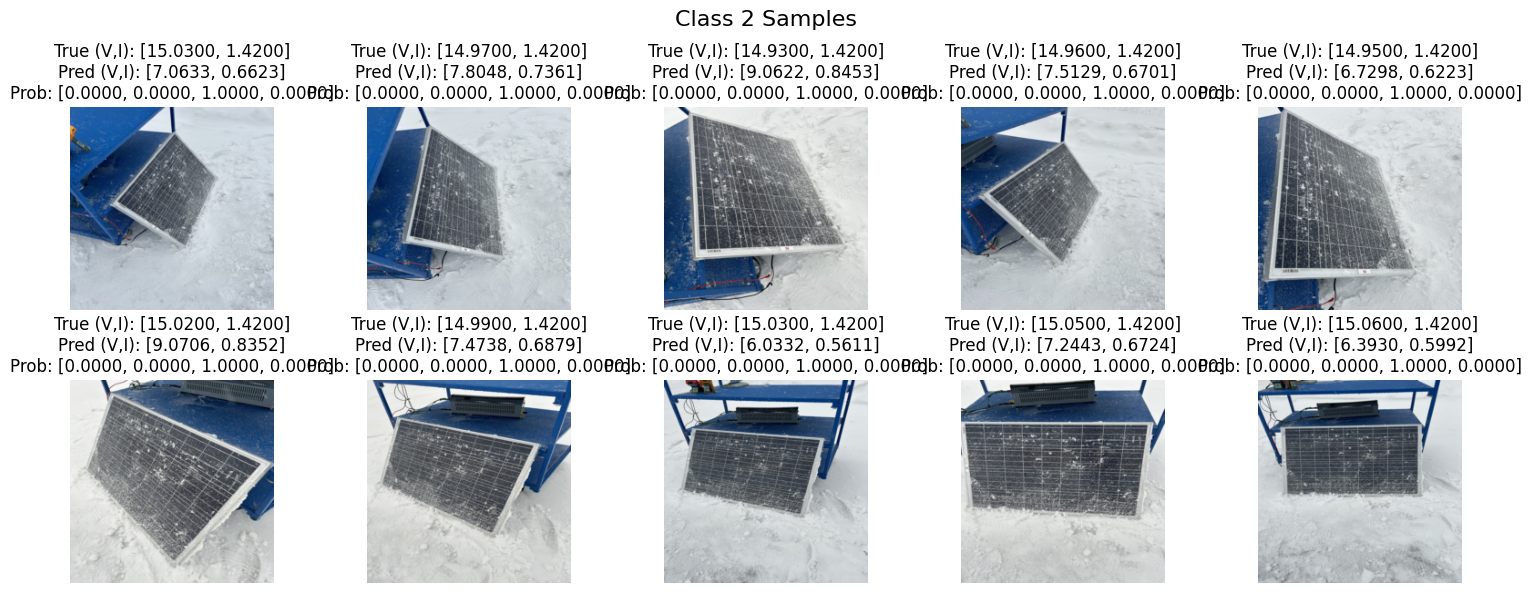

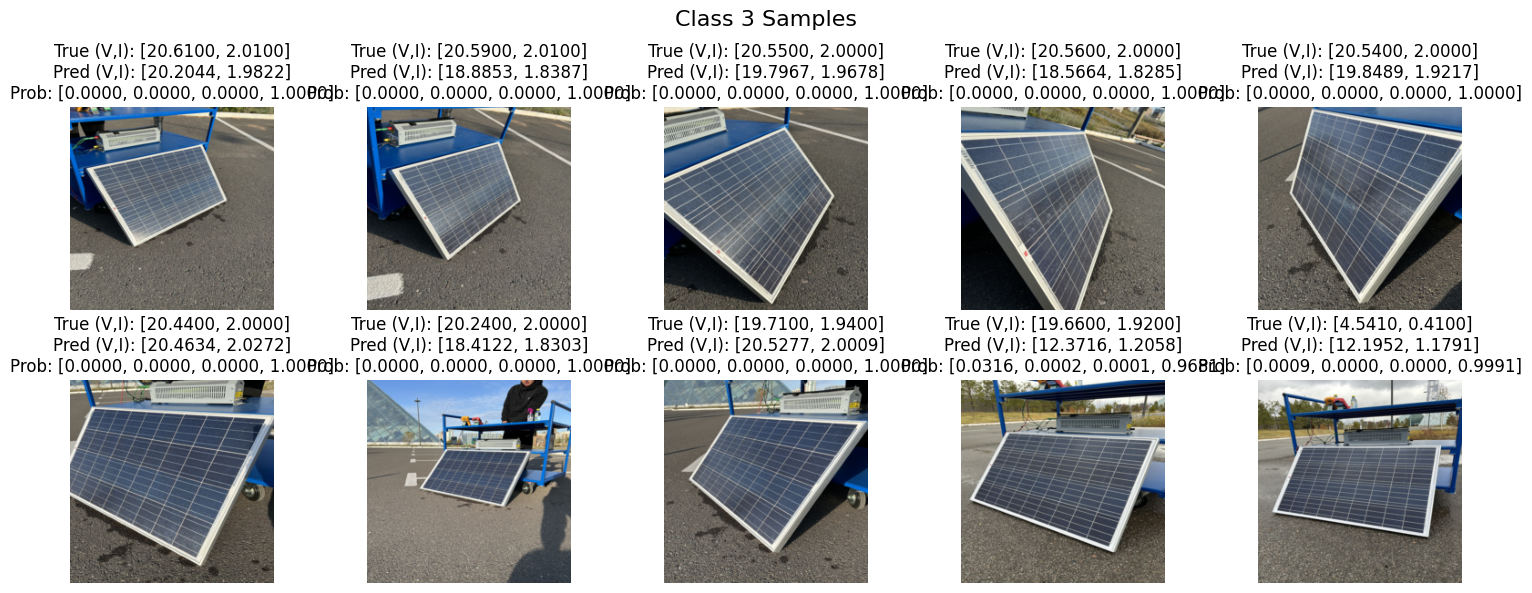

In [ ]:
#5. Run Training, Evaluation, and Visualization
#####################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EfficientNetLite2(num_classes=4)

# Train the model for 100 epochs and save the best model 
model = train_model(model, train_loader, val_loader, device, epochs=100, lr=1e-4)

# save a final checkpoint
checkpoint_path = "efficientNetLite2_best_model_checkpoint.pt"
torch.save(model.state_dict(), checkpoint_path)
print(f"Final checkpoint saved at {checkpoint_path}")

# Evaluate on test set
test_loss, test_reg_mse, test_r2, test_accuracy = evaluate(model, test_loader, device)
print(f"Test Loss: {test_loss:.4f}, Test Reg MSE: {test_reg_mse:.4f}, Test R^2: {test_r2:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Visualize predictions on the test set
visualize_predictions(model, test_loader, device)

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {count_parameters(model)}")

Number of trainable parameters: 7712266
